# Team F1's Linear Regression model

Team members include Patrick, Carter, Jaegeon and Merlin

In [21]:
#importing all the different libraries that we will need for this part. 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
import numpy as np

Here we pull in the data that will to be used for our predictors and qualifiers.  We can pull from two different csv files, but should be careful that they line up. <br>
The list in the X dataframe should contain all the different columns that we want to use, such as "gap_between_mean" or "circuitType_RACE"

In [10]:
# xdata = pd.read_csv(r"C:\Users\merli\Documents\ERDOS\erdos_ds_f1\Merlin preview\gaps and circuit type (no DNF).csv")  #or we can use different files for each, but they should be in the right order
xdata = pd.read_csv("../Merlin preview/gaps and circuit type (cleaned).csv")
ydata = pd.read_csv("../Patrick/Average Local Positions.csv")
xdata2 = pd.read_csv("../paceRankStartPositionDeltas_withDNF.csv")

# xdata = pd.read_csv("gaps_and_circuit_type_(no_DNF).csv")
# ydata = pd.read_csv("../Patrick/Average Local Positions NODNF.csv")
# xdata2 = pd.read_csv("../paceRankStartPositionDeltas.csv")

xdata3 = pd.read_csv("../data_f1db/f1db-races.csv")
xdata3 = xdata3[["id","courseLength", "turns"]]
xdata3 = xdata3.rename(columns={"id":"raceId"})

# ydata = pd.read_csv(r"C:\Users\merli\Documents\ERDOS\erdos_ds_f1\Patrick\Average Local Positions.csv")

# xdata2 = pd.read_csv(r"C:\Users\merli\Documents\ERDOS\erdos_ds_f1\paceRankStartPositionDeltas.csv")

xdata = pd.merge(xdata,xdata2, on = "raceId", how = 'inner')
xdata = pd.merge(xdata,xdata3,on="raceId",how="left")
#xdata = pd.merge(xdata, xdata4, on="raceId", how="left")
xdata["turnDensity"] = xdata["turns"] / xdata["courseLength"]


#"Bgap_mean","Bgap_average" ,"First_ten_gap", "circuitType_STREET"
X  = xdata[ ["Bgap_median","absGridDelta","circuitType_STREET"]]

X = X.fillna(1000)  #getting rid of any nan variables, and replaces them with 1000, for only a couple NaNs, shouldn't make a big different. 


Y = ydata[ "average_local_position"]  #this is our target, what we are trying to predict, and will use this to test our predictive model. 


X_train,X_test , Y_train, Y_test = train_test_split(X,Y , test_size= 0.2, shuffle=True, random_state= 117)


In [11]:
Y.describe()

count    705.000000
mean       2.272555
std        0.942260
min        0.210526
25%        1.555556
50%        2.200000
75%        2.875000
max        5.666667
Name: average_local_position, dtype: float64

In [12]:
#create cross-validation sets for model selection
kfold = KFold(n_splits = 4, shuffle=True, random_state=42)

Here we create the pipeline for how our model will be run.  We are using the Linear Regression model, and we are normalizing our predictor values via StandaScalar.

In [13]:
pipe = Pipeline ([
    ('scalar', StandardScaler() ),  #normalizing our features aka the predictors
    ('model' , LinearRegression() )  # this is the model that we are using, which can be anything we want. 
])

pipe2 = Pipeline ([
    ('scalar', StandardScaler() ),  #normalizing our features aka the predictors
    ('poly', PolynomialFeatures(degree = 2, 
                                  interaction_only= True,
                                  include_bias= False) 
                                  ),
    ('reg' , LinearRegression())  # this is the model that we are using, which can be anything we want. 
])

knnpipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])



Here is where we train the model, making sure not to use any of our testing data.  That would mean there is data leakage. 

In [14]:

pipe2.fit(X_train,Y_train)  #here we are fitting our model with the testing data,  DO NOT INCLUDE THE TEST PARTITIONS




Pipeline(steps=[('scalar', StandardScaler()),
                ('poly',
                 PolynomialFeatures(include_bias=False, interaction_only=True)),
                ('reg', LinearRegression())])

### Model Selection: Look at performance on cross-validation sets

In [15]:
rmses = np.zeros(4)
r2_scores = np.zeros(4)

pipe_to_test = pipe2

for i, (train_index, test_index) in enumerate(kfold.split(X_train, Y_train)):
    X_train_train = X_train.iloc[train_index,:]
    Y_train_train = Y_train.iloc[train_index]

    X_holdout = X_train.iloc[test_index,:]
    Y_holdout = Y_train.iloc[test_index]

    pipe_to_test.fit(X_train_train,Y_train_train)

    y_pred = pipe_to_test.predict(X_holdout)

    rmses[i] = root_mean_squared_error(y_pred, Y_holdout)
    r2_scores[i] = r2_score(Y_holdout,y_pred)

print(rmses, rmses.mean())
print(r2_scores, r2_scores.mean())

[0.80929925 0.93198391 0.86946695 0.86900109] 0.8699377994720361
[0.16610522 0.10378438 0.19329344 0.11999562] 0.14579466532681046


## Final Step: Predict on test set (only after final model is chosen)

Now we can use our trained model to make predictions from the testing predictors, and compare them to the actual predictors from the testing set. 

In [16]:
pipe2.fit(X_train,Y_train)

Y_pred = pipe2.predict(X_test) 

rmse = root_mean_squared_error(Y_pred, Y_test)
r2 = r2_score(Y_test,Y_pred)

print(np.std(Y_test))


print(f"Root Mean squared error: {rmse}")
print(f"R^2 value : {r2}")

0.9236025076447287
Root Mean squared error: 0.8600561565237254
R^2 value : 0.13287159828932438


In [17]:
final = X_test
final["actual"] = Y_test
final["predicted"] = Y_pred
final["delta"] = Y_test - Y_pred

In [18]:
final

,Bgap_median,absGridDelta,circuitType_STREET,actual,predicted,delta
640,135.0,2.700000,False,3.411765,2.642664,0.769101
613,62.0,1.000000,False,3.375000,2.359998,1.015002
471,85.5,1.272727,False,3.263158,2.376926,0.886232
100,158.5,1.230769,False,2.307692,2.268101,0.039591
244,192.0,1.636364,False,1.692308,2.333738,-0.641430
...,...,...,...,...,...,...
218,75.5,0.818182,False,3.000000,2.304828,0.695172
246,206.5,0.000000,False,1.272727,1.849273,-0.576546
478,338.0,2.380952,False,1.714286,2.463781,-0.749495
437,182.5,0.333333,False,2.315789,1.994029,0.321761


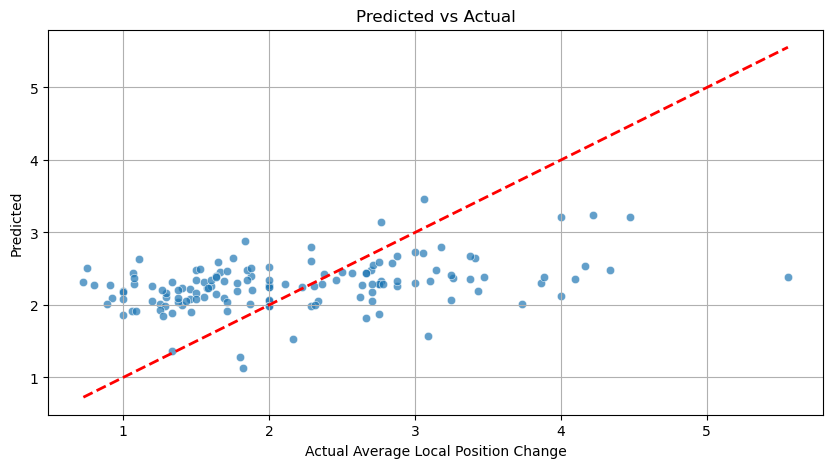

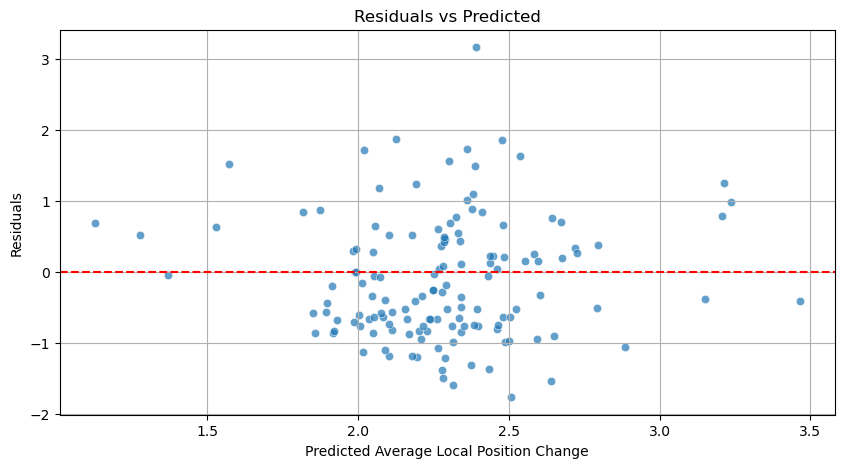

In [22]:
# Predicted vs Actual
plt.figure(figsize=(10, 5))
sns.scatterplot(x=Y_test, y=Y_pred, alpha=0.7)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Average Local Position Change")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.grid(True)
plt.show()

# Residual Plot
residuals = Y_test - Y_pred

plt.figure(figsize=(10, 5))
sns.scatterplot(x=Y_pred, y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Average Local Position Change")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.grid(True)
plt.show()

In [19]:
plt.plot(final["absGridDelta"],final["predicted"],'b.')
plt.plot(final["absGridDelta"],final["actual"],'r.')

NameError: name 'plt' is not defined

In [ ]:
print(Y_pred[98])
print(X_test.iloc[98,:])
print(Y_test.to_list())

0.9948147530989371
Bgap_median            155.5
circuitType_RACE       False
circuitType_ROAD        True
absGridDelta        2.666667
Name: 571, dtype: object
[3.411764705882353, 3.375, 3.263157894736842, 2.3076923076923075, 1.6923076923076923, 1.4, 1.4545454545454546, 3.25, 2.4615384615384617, 1.818181818181818, 1.0, 1.7777777777777777, 2.7058823529411766, 1.7777777777777777, 2.7, 3.4285714285714284, 1.6923076923076923, 1.4, 3.1, 3.25, 0.7272727272727273, 1.5, 2.2857142857142856, 1.75, 1.5555555555555556, 2.75, 1.5, 2.0, 1.875, 3.7333333333333334, 1.3333333333333333, 2.0, 4.222222222222222, 3.0526315789473686, 3.142857142857143, 1.25, 2.5714285714285716, 1.0, 2.375, 1.0769230769230769, 1.4666666666666666, 1.375, 1.0666666666666669, 2.769230769230769, 1.8, 1.0, 3.473684210526316, 1.5714285714285714, 4.095238095238095, 2.75, 1.375, 1.4285714285714286, 2.0, 1.5555555555555556, 1.8461538461538465, 1.3333333333333333, 2.875, 4.0, 1.2, 1.0588235294117647, 0.9230769230769232, 2.625, 1.6, 1.

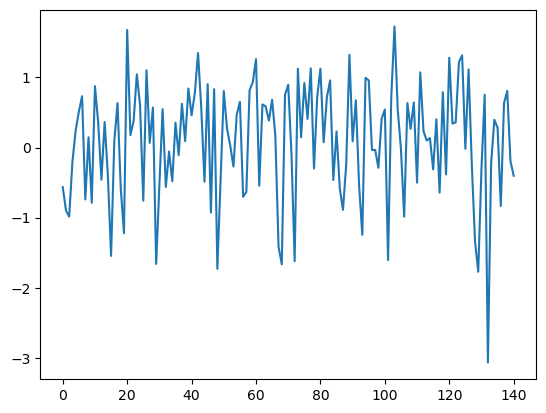

In [ ]:
plt.plot((Y_pred- Y_test.to_list()))


In [ ]:
print(pipe2.named_steps['reg'].coef_)

[-0.20126872  0.35783612  0.01656983  0.0928313  -0.11807794  0.00636434]


In [ ]:
#Visualize using full data
full = X.copy()

pipe2.fit(X,Y)

full["actual"] = Y
full["pred"] = pipe2.predict(X)
full["error"] = full["pred"] - full["actual"]
full["index"] = list(range(len(full)))

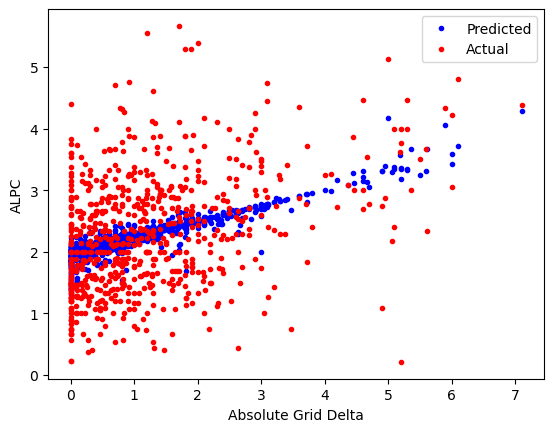

In [ ]:
plt.plot(full["absGridDelta"],full["pred"],'b.')
plt.plot(full["absGridDelta"],full["actual"],'r.')
plt.xlabel("Absolute Grid Delta")
plt.ylabel("ALPC")
plt.legend(["Predicted","Actual"])

<Axes: xlabel='absGridDelta', ylabel='pred'>

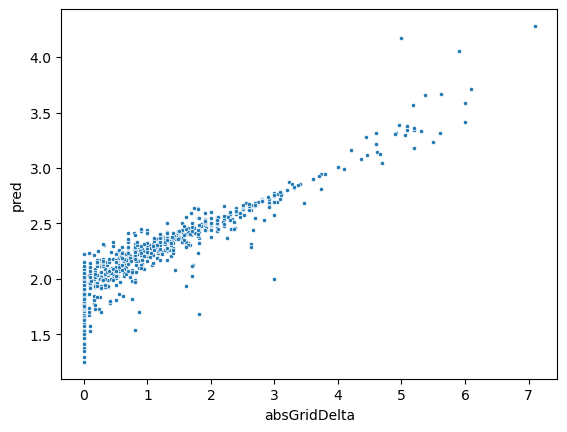

In [ ]:
sns.scatterplot(data=full,x="absGridDelta",y="pred",marker=".")

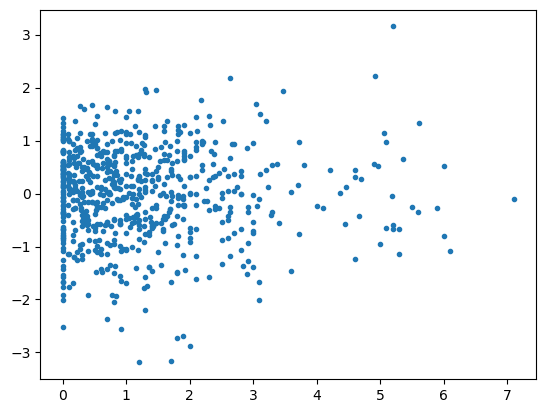

In [ ]:
plt.plot(full["absGridDelta"],full["error"],'.')